In [ ]:
from typing import List, Literal, Union,Any, Dict,Annotated
from pydantic import BaseModel, Field
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage,AnyMessage
import os
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
# Define the State class to hold the conversation state.
class State(TypedDict):
     messages:Annotated[list, add_messages]

# Define the RouteQuery class for query classification.
class RouteQuery(BaseModel):
    datasource: Literal["math_query", "answer_query", "summarize_query"] = Field(
        ..., description="Route to math_query, answer_query, or summarize_query."
    )


def query_condition(
    state: Union[List[AnyMessage], dict[str, Any], BaseModel],
    messages_key: str = "messages",
) -> Literal["math_query", "knowledge_query"]:
    # Extract the last message from the state.
    if isinstance(state, list):
        query = state[-1]
    elif isinstance(state, dict) and (messages := state.get(messages_key, [])):
        query = messages[-1]
    elif messages := getattr(state, messages_key, []):
        query = messages[-1]
    else:
        raise ValueError(f"No messages found in input state: {state}")

    # Use the LLM to classify the query.
    llm = ChatGoogleGenerativeAI(
        model='gemini-2.0-flash-exp',
        api_key=os.getenv('GEMINI_API_KEY')
    )

    system_prompt = """
    You are an expert AI for classifying the user query.
    Classify the following query into one of the following categories:
    1. math_query, for any query that requires solving some mathematical expression 
    2. answer_query, if the question that requires answering a question
    3. summarize_query, for any query that requires summary of a text
    """
    route_prompt = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        ("human", "Classify the following query: {query}"),
    ])

    structured_llm_router = llm.with_structured_output(RouteQuery)
    question_router = route_prompt | structured_llm_router
    response = question_router.invoke({"query": query})

    return response.datasource

# Function to extract the query from the state.
def get_query(state: State):
    return {"messages": state['messages']}

# Function to handle math queries directly using the LLM.
def math_ai(state: State):
    query = state["messages"][-1]  # Get the last message (user query).
    llm = ChatGoogleGenerativeAI(
        model='gemini-2.0-flash-exp',
        api_key=os.getenv('GEMINI_API_KEY')
    )
    # Use the LLM to solve the math query directly.
    result = llm.invoke(f"Solve the following math query: {query}")
    return {"messages": [result]}

# Function to handle  question answering(Llama agent).
def answer_agent_ai(state: State):
    last_message = state['messages'][-1].content
    # Simulate a question answering (replace with actual Llama agent call).
    answer = f"answer of '{last_message}': It is asking for answer of the given question."
    return {"messages": [answer]}

#function t handle summarization
def summarize_ai(state: State):
    last_message = state['messages'][-1].content
    # Simulate a summarization (replace with actual summarization call).
    summary = f"Summary of '{last_message}': It is asking for summarization of the given text."
    return {"messages": [summary]}


# Initialize the graph builder.
graph_builder = StateGraph(State)

# Add nodes to the graph.
graph_builder.add_node("get_query", get_query)  # Extract the query.
graph_builder.add_node("math_operation", math_ai)  # Handle math queries.
graph_builder.add_node("Question_answering", answer_agent_ai)  # Handle knowledge queries.
graph_builder.add_node("summarize_ai", summarize_ai)  # Handle summarization.

# Add edges to define the flow.
graph_builder.add_edge(START, "get_query")  # Start with extracting the query.
graph_builder.add_conditional_edges(
    "get_query",
    query_condition,  # Classify the query.
    {
        'math_query': 'math_operation',  # Route to math query handler.
        'answer_query': 'Question_answering',  # Route to knowledge query handler.
        'summarize_query': 'summarize_ai'  # Route to summarization handler.
    }
)
graph_builder.add_edge("math_operation", END)  # End after handling math queries.
graph_builder.add_edge('Question_answering', END)  # End after handling knowledge queries.
graph_builder.add_edge('summarize_ai', END)  # End after handling summarization.
# Compile the graph.
graph = graph_builder.compile()

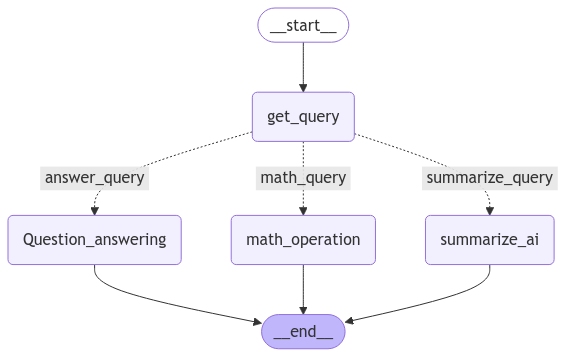

In [10]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
graph_memory = graph_builder.compile(checkpointer=memory)

config = {"configurable": {"thread_id": "1"}}

In [12]:
from IPython.display import clear_output

while True:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Goodbye!")
        break
    clear_output(wait=True)
    messages = graph_memory.invoke({"messages": [HumanMessage(content=user_input)]},config)
    for m in messages['messages']:
        m.pretty_print()

================================ Human Message =================================

i am eating apple daily 
================================ Human Message =================================

answer of 'i am eating apple daily ': It is asking for answer of the given question.
================================ Human Message =================================

i want to know abt something that i dont know and i am very much focused on it 
================================ Human Message =================================

answer of 'i want to know abt something that i dont know and i am very much focused on it ': It is asking for answer of the given question.
Goodbye!
